In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"atharair","key":"ea8dd728b8608671acdde733b3dafadc"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install kaggle

In [ ]:
!kaggle datasets download -d ruchi798/data-science-job-salaries
!unzip data-science-job-salaries.zip

Dataset URL: https://www.kaggle.com/datasets/ruchi798/data-science-job-salaries
License(s): CC0-1.0
100% 7.37k/7.37k [00:00<00:00, 15.2MB/s]

Archive:  data-science-job-salaries.zip
  inflating: ds_salaries.csv         


In [ ]:
!ls

 data-science-job-salaries.zip	'kaggle (1).json'   sample_data
 ds_salaries.csv		 kaggle.json


In [ ]:
import pandas as pd
df = pd.read_csv('ds_salaries.csv')
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


In [ ]:
df.isnull().sum()
df.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


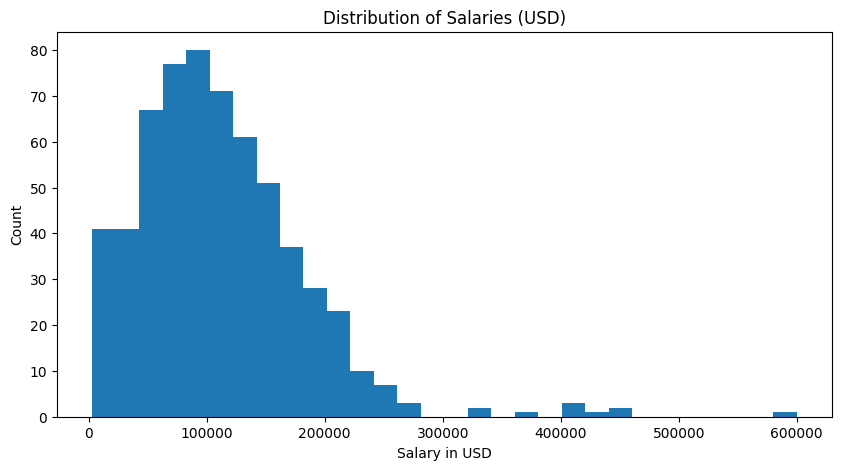

,salary_in_usd
count,607.000000
mean,112297.869852
std,70957.259411
min,2859.000000
25%,62726.000000
50%,101570.000000
75%,150000.000000
max,600000.000000


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df['salary_in_usd'], bins=30)
plt.title('Distribution of Salaries (USD)')
plt.xlabel('Salary in USD')
plt.ylabel('Count')
plt.show()

df['salary_in_usd'].describe()

In [ ]:
df.groupby('experience_level')['salary_in_usd'].mean().sort_values(ascending=False)

,salary_in_usd
experience_level,
EX,199392.038462
SE,138617.292857
MI,87996.056338
EN,61643.318182


In [ ]:

df.groupby('employment_type')['salary_in_usd'].mean().sort_values(ascending=False)

,salary_in_usd
employment_type,
CT,184575.000000
FT,113468.073129
FL,48000.000000
PT,33070.500000


In [ ]:
df['job_title'].value_counts().head(10)

,count
job_title,
Data Scientist,143
Data Engineer,132
Data Analyst,97
Machine Learning Engineer,41
Research Scientist,16
Data Science Manager,12
Data Architect,11
Machine Learning Scientist,8
Big Data Engineer,8


In [ ]:
df.groupby('remote_ratio')['salary_in_usd'].mean().sort_values(ascending=False)

,salary_in_usd
remote_ratio,
100,122457.454068
0,106354.622047
50,80823.030303


In [ ]:
df_model = df[['work_year', 'experience_level', 'employment_type', 'job_title',
               'remote_ratio', 'company_size', 'salary_in_usd']].copy()

In [ ]:
df_encoded = pd.get_dummies(df_model, columns=['experience_level', 'employment_type',
                                                  'job_title', 'company_size'], drop_first=True)

In [ ]:
df_encoded.shape

(607, 60)

In [ ]:
df_encoded.head()

,work_year,remote_ratio,salary_in_usd,experience_level_EX,experience_level_MI,experience_level_SE,employment_type_FL,employment_type_FT,employment_type_PT,job_title_AI Scientist,...,job_title_Marketing Data Analyst,job_title_NLP Engineer,job_title_Principal Data Analyst,job_title_Principal Data Engineer,job_title_Principal Data Scientist,job_title_Product Data Analyst,job_title_Research Scientist,job_title_Staff Data Scientist,company_size_M,company_size_S
0,2020,0,79833,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2020,0,260000,False,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
2,2020,50,109024,False,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
3,2020,0,20000,False,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,True
4,2020,50,150000,False,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['salary_in_usd'])
y = df_encoded['salary_in_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(485, 59) (122, 59)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = RandomForestRegressor(n_estimators=100, random_state=42)

In [ ]:
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"R² Score: {r2:.3f}")

MAE: $37,896
RMSE: $55,946
R² Score: 0.183


In [ ]:
title_counts = df['job_title'].value_counts()
print(title_counts)

job_title
Data Scientist                              143
Data Engineer                               132
Data Analyst                                 97
Machine Learning Engineer                    41
Research Scientist                           16
Data Science Manager                         12
Data Architect                               11
Machine Learning Scientist                    8
Big Data Engineer                             8
Director of Data Science                      7
AI Scientist                                  7
Principal Data Scientist                      7
Data Science Consultant                       7
Data Analytics Manager                        7
BI Data Analyst                               6
Computer Vision Engineer                      6
ML Engineer                                   6
Lead Data Engineer                            6
Applied Data Scientist                        5
Business Data Analyst                         5
Data Engineering Manager      

In [ ]:
title_counts = df['job_title'].value_counts()
common_titles = title_counts[title_counts > 10].index


In [ ]:
df_model = df[['work_year', 'experience_level', 'employment_type', 'job_title',
               'remote_ratio', 'company_size', 'salary_in_usd']].copy()

In [ ]:
df_model['job_title'] = df_model['job_title'].apply(lambda x: x if x in common_titles else 'Other')


In [ ]:
print(df_model['job_title'].value_counts())

job_title
Other                        155
Data Scientist               143
Data Engineer                132
Data Analyst                  97
Machine Learning Engineer     41
Research Scientist            16
Data Science Manager          12
Data Architect                11
Name: count, dtype: int64


In [ ]:
df_model.head()

,work_year,experience_level,employment_type,job_title,remote_ratio,company_size,salary_in_usd
0,2020,MI,FT,Data Scientist,0,L,79833
1,2020,SE,FT,Other,0,S,260000
2,2020,SE,FT,Other,50,M,109024
3,2020,MI,FT,Other,0,S,20000
4,2020,SE,FT,Machine Learning Engineer,50,L,150000


In [ ]:
df_encoded.shape

(607, 60)

In [ ]:
df_model.shape

(607, 7)

In [ ]:
df_encoded = pd.get_dummies(df_model, columns=['experience_level', 'employment_type',
                                                  'job_title', 'company_size'], drop_first=True)
print(df_encoded.shape)



(607, 18)


In [ ]:
X = df_encoded.drop(columns=['salary_in_usd'])
y = df_encoded['salary_in_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(485, 17) (122, 17)


In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"R² Score: {r2:.3f}")

MAE: $39,841
RMSE: $56,499
R² Score: 0.167


In [ ]:
df.groupby('company_location')['salary_in_usd'].mean().sort_values(ascending=False).head(12)

,salary_in_usd
company_location,
RU,157500.000000
US,144055.261972
NZ,125000.000000
IL,119059.000000
JP,114127.333333
AU,108042.666667
DZ,100000.000000
AE,100000.000000
IQ,100000.000000


In [ ]:
location_counts = df['company_location'].value_counts()
common_locations = location_counts[location_counts > 10].index

df_model = df[['work_year', 'experience_level', 'employment_type', 'job_title',
               'remote_ratio', 'company_size', 'company_location', 'salary_in_usd']].copy()

df_model['job_title'] = df_model['job_title'].apply(lambda x: x if x in common_titles else 'Other')
df_model['company_location'] = df_model['company_location'].apply(lambda x: x if x in common_locations else 'Other')

print(df_model['company_location'].value_counts())

company_location
US       355
Other     83
GB        47
CA        30
DE        28
IN        24
FR        15
ES        14
GR        11
Name: count, dtype: int64


In [ ]:
df_encoded = pd.get_dummies(df_model, columns=['experience_level', 'employment_type',
                                                  'job_title', 'company_size', 'company_location'],
                              drop_first=True)

In [ ]:
X = df_encoded.drop(columns=['salary_in_usd'])
y = df_encoded['salary_in_usd']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"R² Score: {r2:.3f}")

MAE: $31,442
RMSE: $51,416
R² Score: 0.310


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

In [ ]:
grid_search = GridSearchCV(RandomForestRegressor(random_state=42),
                             param_grid, cv=5,
                             scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV R² score:", grid_search.best_score_)

Best parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R² score: 0.3934208826829143


In [ ]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

In [ ]:

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Tuned MAE: ${mae_tuned:,.0f}")
print(f"Tuned RMSE: ${rmse_tuned:,.0f}")
print(f"Tuned R²: {r2_tuned:.3f}")

Tuned MAE: $32,548
Tuned RMSE: $48,540
Tuned R²: 0.385


In [ ]:
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Tuned MAE: ${mae_tuned:,.0f}")
print(f"Tuned RMSE: ${rmse_tuned:,.0f}")
print(f"Tuned R²: {r2_tuned:.3f}")

Tuned MAE: $32,548
Tuned RMSE: $48,540
Tuned R²: 0.385


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
exp_map = {'EN': 1, 'MI': 2, 'SE': 3, 'EX': 4}
df['experience_numeric'] = df['experience_level'].map(exp_map)


In [ ]:
cluster_features = df[['salary_in_usd', 'remote_ratio', 'experience_numeric']].copy()

In [ ]:
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

cluster_scaled[:5]

array([[-0.45790445, -1.74361532, -0.51216219],
       [ 2.08328151, -1.74361532,  0.7619462 ],
       [-0.04617667, -0.51437665,  0.7619462 ],
       [-1.30182581, -1.74361532, -0.51216219],
       [ 0.53177399, -0.51437665,  0.7619462 ]])

In [ ]:
import matplotlib.pyplot as plt

inertia = []
k_range = range(1, 11)


In [ ]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)


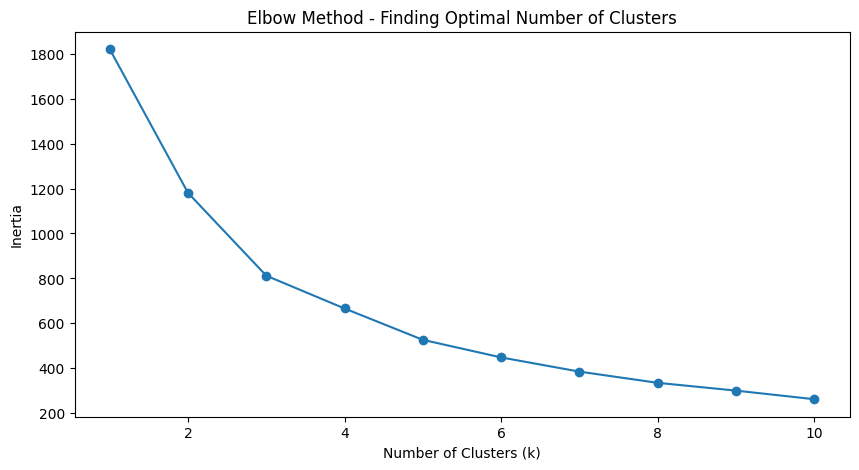

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method - Finding Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(cluster_scaled)

In [ ]:
df.groupby('cluster')[['salary_in_usd', 'remote_ratio', 'experience_numeric']].mean()

,salary_in_usd,remote_ratio,experience_numeric
cluster,,,
0,244352.028986,90.579710,2.985507
1,72176.885845,85.388128,1.666667
2,100193.846774,0.403226,2.338710
3,118326.882051,92.564103,3.061538


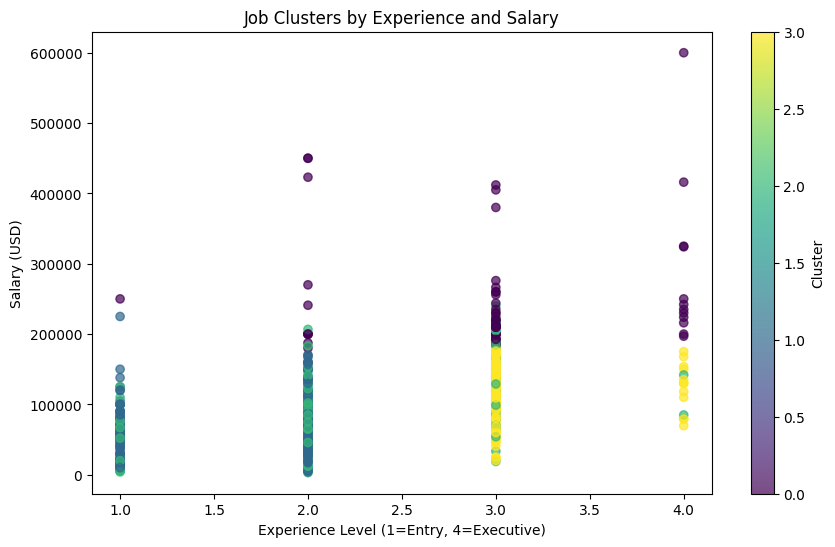

In [ ]:
plt.figure(figsize=(10,6))
scatter = plt.scatter(df['experience_numeric'], df['salary_in_usd'], c=df['cluster'], cmap='viridis', alpha=0.7)
plt.xlabel('Experience Level (1=Entry, 4=Executive)')
plt.ylabel('Salary (USD)')
plt.title('Job Clusters by Experience and Salary')
plt.colorbar(scatter, label='Cluster')
plt.show()

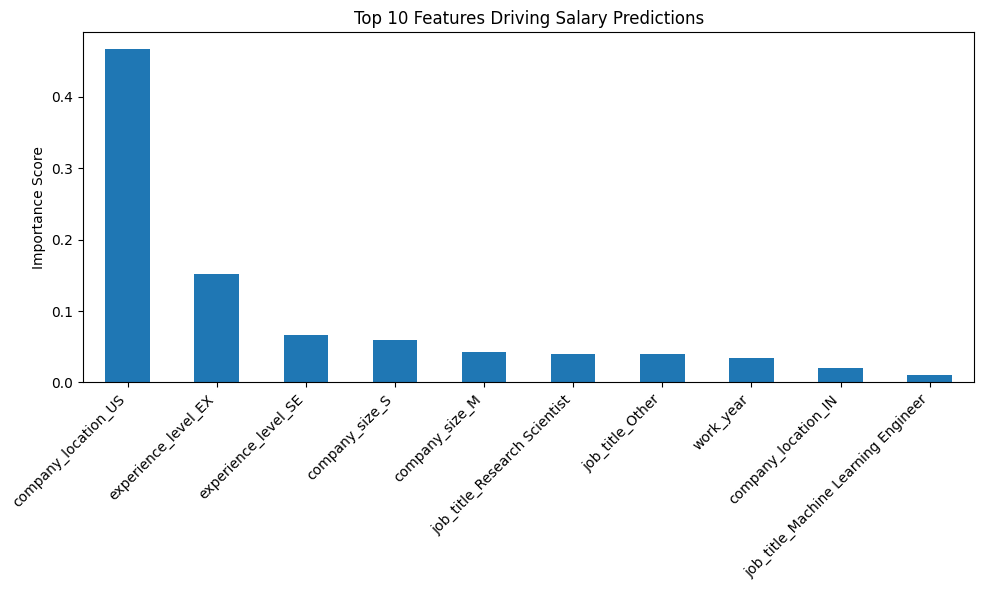

company_location_US                    0.467227
experience_level_EX                    0.151545
experience_level_SE                    0.066800
company_size_S                         0.060021
company_size_M                         0.042581
job_title_Research Scientist           0.040114
job_title_Other                        0.039407
work_year                              0.034524
company_location_IN                    0.019807
job_title_Machine Learning Engineer    0.010047
dtype: float64


In [ ]:
feature_importance = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
feature_importance.plot(kind='bar')
plt.title('Top 10 Features Driving Salary Predictions')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(feature_importance)